# Bounding Box Evaluation for Organ Detection

This notebook evaluates vision-language models on bounding box localization for surgical organ detection.

**Key Features:**
- Uses 200 balanced test samples with 30% minimum quota for rare classes
- Evaluates both zero-shot and few-shot (with bounding box examples)
- Supports multiple datasets (CholecSeg8k, CholecOrgans, CholecGoNoGo)
- Computes IoU metrics and presence detection accuracy

## Setup and Imports

In [1]:
import os
import sys
import json
from pathlib import Path
from datetime import datetime
import numpy as np
import pandas as pd
from typing import Dict, List, Tuple, Optional, Any
from tqdm import tqdm
import pickle

# Add src to path
sys.path.insert(0, '/shared_data0/weiqiuy/llm_cholec_organ/src')

# Load API keys first
api_keys_file = Path("/shared_data0/weiqiuy/llm_cholec_organ/API_KEYS2.json")
if api_keys_file.exists():
    with open(api_keys_file, "r") as f:
        api_keys = json.load(f)
    
    os.environ['OPENAI_API_KEY'] = api_keys.get('OPENAI_API_KEY', '')
    os.environ['ANTHROPIC_API_KEY'] = api_keys.get('ANTHROPIC_API_KEY', '')
    os.environ['GOOGLE_API_KEY'] = api_keys.get('GOOGLE_API_KEY', '')

# Import from endopoint package - use the local adapter since we're using local dataset
from endopoint.datasets.cholecseg8k_local import CholecSeg8kLocalAdapter
from endopoint.eval.bbox_evaluator import BoundingBoxEvaluator

# Import dataset
from datasets import load_dataset

print("✅ Modules imported")

✅ Modules imported


## Configuration

In [19]:
# Dataset configuration - easily changeable
DATASET_NAME = "cholecseg8k_local"  # Use the local version that has the balanced files

# Evaluation configuration
EVAL_CONFIG = {
    "num_samples": None,  # None = use all 200 test samples, or specify a number
    "use_cache": True,    # Use cached model responses
    "min_pixels": 50,     # Minimum pixels for valid bbox
}

# Output configuration
USE_TIMESTAMP = False  # Set to True for experiments, False for persistent results
QUICK_TEST = False # True     # Run ablation with just 5 samples for quick testing
ABLATION_SAMPLES = 5  # Number of samples for ablation study

# Models to evaluate
MODELS = [
    "gpt-4.1",
    # "claude-sonnet-4-20250514",
    # "gemini-2.0-flash",
]

if QUICK_TEST:
    EVAL_CONFIG["num_samples"] = ABLATION_SAMPLES
    print(f"🚀 Running in QUICK TEST mode ({ABLATION_SAMPLES} samples)")
    print("   Set QUICK_TEST=False for full 200-sample evaluation")

# Set output directory based on timestamp flag
if USE_TIMESTAMP:
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    OUTPUT_DIR = Path(f"/shared_data0/weiqiuy/llm_cholec_organ/results/bbox_{DATASET_NAME}_{timestamp}")
    print(f"📁 Using timestamped output directory (experiments)")
else:
    OUTPUT_DIR = Path(f"/shared_data0/weiqiuy/llm_cholec_organ/results/bbox_{DATASET_NAME}")
    print(f"📁 Using persistent output directory (production/incremental)")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Dataset: {DATASET_NAME}")
print(f"Models: {MODELS}")
print(f"Samples: {EVAL_CONFIG['num_samples'] or 'all 200'}")
print(f"Output: {OUTPUT_DIR}")
print(f"Timestamp mode: {'Enabled' if USE_TIMESTAMP else 'Disabled'}")

📁 Using persistent output directory (production/incremental)
Dataset: cholecseg8k_local
Models: ['gpt-4.1']
Samples: all 200
Output: /shared_data0/weiqiuy/llm_cholec_organ/results/bbox_cholecseg8k_local
Timestamp mode: Disabled


## Load Dataset and Test Indices

In [20]:
# Load dataset
print(f"\n📊 Loading dataset: {DATASET_NAME}...")

# For local dataset, we use the local adapter
if DATASET_NAME == "cholecseg8k_local":
    # Load from local files
    data_dir = "/shared_data0/weiqiuy/datasets/cholecseg8k"
    dataset_adapter = CholecSeg8kLocalAdapter(data_dir=data_dir)
    # We'll access examples through the adapter
    dataset = None  # Will use adapter's get_example method
    print(f"✅ Local dataset loaded from {data_dir}")
    print(f"  Train: {dataset_adapter.total('train')} samples")
    print(f"  Test: {dataset_adapter.total('test')} samples")
else:
    # Load from HuggingFace
    dataset = load_dataset("minwoosun/CholecSeg8k")
    from endopoint.datasets.cholecseg8k import CholecSeg8kAdapter
    dataset_adapter = CholecSeg8kAdapter()
    print(f"✅ HuggingFace dataset loaded")
    print(f"  Train: {len(dataset['train'])} samples")

print(f"  Classes: {len(dataset_adapter.label_ids)}")
print(f"  Organ IDs: {dataset_adapter.label_ids}")

# Get image dimensions from first sample
if dataset is not None:
    example = dataset['train'][0]
else:
    example = dataset_adapter.get_example('train', 0)
    
img_width, img_height = example['image'].size
print(f"  Image dimensions: {img_width}x{img_height}")


📊 Loading dataset: cholecseg8k_local...
Video-based split created:
  Total videos: 17
  Train: 13 videos, 5760 frames
  Validation: 1 videos, 560 frames
  Test: 3 videos, 1760 frames
  Train videos: video01, video09, video20, video52, video35, video48, video26, video43, video12, video27, video55, video18, video25
  Val videos: video28
  Test videos: video37, video17, video24
✅ Local dataset loaded from /shared_data0/weiqiuy/datasets/cholecseg8k
  Train: 5760 samples
  Test: 1760 samples
  Classes: 12
  Organ IDs: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
  Image dimensions: 854x480


In [21]:
# Check dataset structure
print("\nChecking dataset structure...")

# Get a sample based on whether we're using dataset or adapter
if dataset is not None:
    sample = dataset['train'][0]
else:
    sample = dataset_adapter.get_example('train', 0)
    
print(f"Available keys in dataset: {list(sample.keys())}")
if 'color_mask' in sample:
    print(f"  color_mask shape: {np.array(sample['color_mask']).shape}")
if 'mask' in sample:
    print(f"  mask shape: {np.array(sample['mask']).shape}")


Checking dataset structure...
Available keys in dataset: ['image', 'color_mask', 'mask_path', 'watershed_mask_path', 'video_id', 'frame_id']
  color_mask shape: (480, 854, 3)


In [22]:
# Load balanced test indices
data_dir = Path(f"/shared_data0/weiqiuy/llm_cholec_organ/data_info/{DATASET_NAME}_balanced_200")

# Try different possible filenames
possible_files = [
    data_dir / "balanced_test_indices_advanced_200.json",
    data_dir / "balanced_test_indices.json"
]

test_indices = None
for indices_file in possible_files:
    if indices_file.exists():
        with open(indices_file, 'r') as f:
            test_data = json.load(f)
        
        # Handle different formats
        if 'indices' in test_data:
            test_indices = test_data['indices']
        elif 'test_indices' in test_data:
            test_indices = test_data['test_indices']
        print(f"✅ Loaded {len(test_indices)} balanced test samples from {indices_file.name}")
        break

if test_indices is None:
    print(f"❌ Test indices not found in {data_dir}")
    print("Please run notebooks/test_unified_fewshot_simplified.ipynb first")
else:
    # Apply num_samples limit if specified
    if EVAL_CONFIG['num_samples'] and EVAL_CONFIG['num_samples'] < len(test_indices):
        # Use linspace for even sampling
        selected_idx = np.linspace(0, len(test_indices)-1, EVAL_CONFIG['num_samples'], dtype=int)
        test_indices = [test_indices[i] for i in selected_idx]
        print(f"📌 Using {len(test_indices)} evenly spaced samples for evaluation")

✅ Loaded 200 balanced test samples from balanced_test_indices_advanced_200.json


## Load Few-Shot Plan

In [23]:
# Load few-shot bounding box plan
possible_plan_files = [
    data_dir / "fewshot_plan_bbox_200.json",
    data_dir / "fewshot_plan_bbox_n200.json"
]

fewshot_plan = None
for plan_file in possible_plan_files:
    if plan_file.exists():
        with open(plan_file, 'r') as f:
            fewshot_plan = json.load(f)
        print(f"✅ Loaded few-shot bbox plan from {plan_file.name}")
        
        # Print summary
        if 'plan' in fewshot_plan:
            total_pos = sum(len(info.get('positives', [])) for info in fewshot_plan['plan'].values())
            total_neg_absent = sum(len(info.get('negatives_absent', [])) for info in fewshot_plan['plan'].values())
            total_neg_wrong = sum(len(info.get('negatives_wrong_bbox', [])) for info in fewshot_plan['plan'].values())
            print(f"  Examples: {total_pos} positive, {total_neg_absent} negative (absent), {total_neg_wrong} negative (wrong bbox)")
        break

if fewshot_plan is None:
    print(f"⚠️ Few-shot bbox plan not found in {data_dir}")
    print("Will run zero-shot only")

✅ Loaded few-shot bbox plan from fewshot_plan_bbox_200.json
  Examples: 12 positive, 11 negative (absent), 13 negative (wrong bbox)


In [24]:
# Initialize the evaluator  
from endopoint.eval.bbox_evaluator import BoundingBoxEvaluator

evaluator = BoundingBoxEvaluator(
    models=MODELS,
    dataset=dataset,  # This is None for local dataset
    dataset_adapter=dataset_adapter,  # This handles data access
    canvas_width=img_width,   # Use original dimensions
    canvas_height=img_height,
    output_dir=OUTPUT_DIR,
    use_cache=EVAL_CONFIG['use_cache'],
    min_pixels=EVAL_CONFIG['min_pixels'],
    use_timestamp=USE_TIMESTAMP  # Control output directory naming
)

print(f"✅ Evaluator initialized")
print(f"  Using adapter: {dataset_adapter.dataset_tag}")
print(f"  Canvas: {img_width}x{img_height}")
print(f"  Output: {evaluator.output_dir}")
print(f"  Timestamp mode: {'Enabled' if USE_TIMESTAMP else 'Disabled'}")

if not USE_TIMESTAMP:
    print(f"  📋 In persistent mode - existing results will be reused to avoid redundant API calls")

✅ Evaluator initialized
  Using adapter: cholecseg8k_local
  Canvas: 854x480
  Output: /shared_data0/weiqiuy/llm_cholec_organ/results/bbox_cholecseg8k_local
  Timestamp mode: Disabled
  📋 In persistent mode - existing results will be reused to avoid redundant API calls


📸 Using test example at index 860


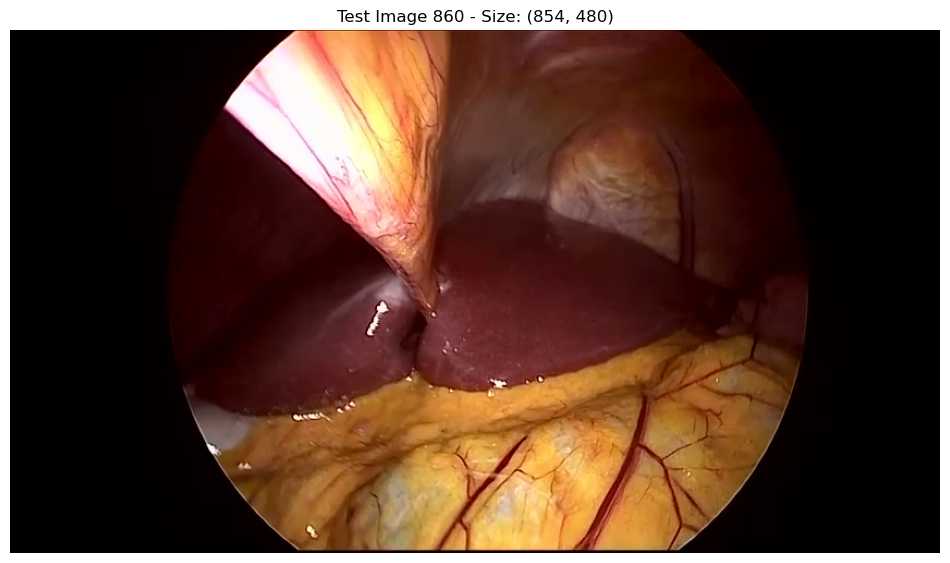


🎯 Ground Truth - Present organs: Abdominal Wall, Liver, Gastrointestinal Tract, Fat, Gallbladder

📦 Ground Truth Bounding Boxes:
  Abdominal Wall: [145, 1, 734, 325]
  Liver: [159, 153, 670, 357]
  Gastrointestinal Tract: [649, 225, 734, 305]
  Fat: [187, 276, 725, 478]
  Gallbladder: [160, 326, 226, 390]


In [25]:
# Example: Show raw prompts and outputs for one test image
import matplotlib.pyplot as plt
from PIL import Image
import json

# Select first test example
example_idx = test_indices[0] if test_indices else 0
print(f"📸 Using test example at index {example_idx}")

# Get the example
example = dataset_adapter.get_example('test', example_idx)
image = example['image']

# Convert to tensors to get ground truth
img_tensor, lab_tensor = dataset_adapter.example_to_tensors(example)

# Display the image
fig, ax = plt.subplots(1, 1, figsize=(12, 8))
ax.imshow(image)
ax.set_title(f"Test Image {example_idx} - Size: {image.size}")
ax.axis('off')
plt.show()

# Get ground truth presence
presence_gt = dataset_adapter.labels_to_presence_vector(lab_tensor, min_pixels=50)
present_organs = [dataset_adapter.id2label[i+1] for i, p in enumerate(presence_gt) if p == 1]
print(f"\n🎯 Ground Truth - Present organs: {', '.join(present_organs)}")

# Compute ground truth bounding boxes
import cv2
import numpy as np

gt_bboxes = {}
for class_id in dataset_adapter.label_ids:
    mask = (lab_tensor.numpy() == class_id).astype(np.uint8)
    if mask.sum() >= 50:  # min_pixels threshold
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if contours:
            x, y, w, h = cv2.boundingRect(contours[0])
            for contour in contours[1:]:
                x2, y2, w2, h2 = cv2.boundingRect(contour)
                x = min(x, x2)
                y = min(y, y2)
                w = max(x + w, x2 + w2) - x
                h = max(y + h, y2 + h2) - y
            gt_bboxes[dataset_adapter.id2label[class_id]] = [x, y, x+w, y+h]

print(f"\n📦 Ground Truth Bounding Boxes:")
for organ, bbox in gt_bboxes.items():
    print(f"  {organ}: [{bbox[0]}, {bbox[1]}, {bbox[2]}, {bbox[3]}]")

## Example: Raw Prompts and Model Outputs

Let's examine the actual prompts sent to models and their raw responses for one test example.

In [26]:
# Generate prompts and get model outputs for this example
# NOTE: The actual evaluator queries each organ SEPARATELY (12 API calls per image) 
# or COMBINED (1 API call per image) depending on the mode

from endopoint.prompts.bbox_prompts import get_bbox_prompt, get_combined_bbox_prompt
from endopoint.models import create_model
import re

# Test with each model
model_outputs = {}

for model_name in MODELS[:1]:  # Just test first model for now
    print(f"\n{'='*80}")
    print(f"MODEL: {model_name}")
    print('='*80)
    
    # Initialize model
    model = create_model(model_name, use_cache=True)
    
    # System prompt for the model
    system_prompt = "You are an expert medical image analyst specializing in laparoscopic surgery organ detection."
    
    print("\n" + "="*60)
    print("APPROACH 1: SEPARATE QUERIES (as used in separate mode)")
    print("="*60)
    print("The evaluator makes one API call per organ (12 calls total per image)")
    
    # Example: Query for just one organ (Liver)
    organ_id = 2  # Liver
    organ_name = dataset_adapter.id2label[organ_id]
    
    # Generate prompt for a single organ using the function
    single_organ_prompt = get_bbox_prompt(
        organ_name=organ_name,
        prompt_type="standard",
        use_fewshot=False,
        canvas_width=img_width,
        canvas_height=img_height
    )
    
    print(f"\n📝 ZERO-SHOT PROMPT for '{organ_name}':")
    print("-" * 40)
    print(single_organ_prompt[:800] + "..." if len(single_organ_prompt) > 800 else single_organ_prompt)
    
    # Get model response for single organ
    print(f"\n🤖 Getting {model_name} response for '{organ_name}'...")
    response_single = model([(image, single_organ_prompt)], system_prompt=system_prompt)[0]
    
    print(f"\n📤 RAW MODEL OUTPUT for '{organ_name}':")
    print("-" * 40)
    print(response_single[:500] + "..." if len(response_single) > 500 else response_single)
    
    print("\n" + "="*60)
    print("APPROACH 2: COMBINED QUERY (as used in combined mode)")
    print("="*60)
    print("This asks for all organs at once (more efficient)")
    
    # Combined prompt for all organs using the new function
    organ_names = [dataset_adapter.id2label[i] for i in dataset_adapter.label_ids]
    combined_prompt = get_combined_bbox_prompt(
        organ_names=organ_names,
        prompt_type="standard",
        use_fewshot=False,
        canvas_width=img_width,
        canvas_height=img_height
    )
    
    print("\n📝 COMBINED PROMPT (all organs):")
    print("-" * 40)
    print(combined_prompt[:800] + "..." if len(combined_prompt) > 800 else combined_prompt)
    
    # Get model response for all organs
    print(f"\n🤖 Getting {model_name} response for all organs...")
    response_combined = model([(image, combined_prompt)], system_prompt=system_prompt)[0]
    
    print("\n📤 RAW MODEL OUTPUT (all organs):")
    print("-" * 40)
    print(response_combined[:1500] + "..." if len(response_combined) > 1500 else response_combined)
    
    # Parse the combined response
    try:
        json_match = re.search(r'\{.*\}', response_combined, re.DOTALL)
        if json_match:
            parsed = json.loads(json_match.group())
            print("\n✅ PARSED OUTPUT:")
            print(json.dumps(parsed, indent=2)[:1000] + "..." if len(json.dumps(parsed, indent=2)) > 1000 else json.dumps(parsed, indent=2))
            
            # Show which organs were detected
            detected = [organ for organ, data in parsed.items() if data.get('present', False)]
            print(f"\n🔍 Detected organs: {', '.join(detected)}")
            
            # Compare with ground truth
            gt_set = set(present_organs)
            detected_set = set(detected)
            print(f"\n📊 Comparison with ground truth:")
            print(f"  Correct detections: {gt_set & detected_set}")
            print(f"  False positives: {detected_set - gt_set}")
            print(f"  Missed organs: {gt_set - detected_set}")
            
    except Exception as e:
        print(f"\n❌ Failed to parse JSON: {e}")
    
    model_outputs[model_name] = {
        'single_organ': response_single,
        'combined': response_combined
    }


MODEL: gpt-4.1

APPROACH 1: SEPARATE QUERIES (as used in separate mode)
The evaluator makes one API call per organ (12 calls total per image)

📝 ZERO-SHOT PROMPT for 'Liver':
----------------------------------------
Detect the organ "Liver" in this surgical image.

Canvas size: 854x480 pixels (origin at top-left)

If the organ is present (≥50 pixels visible), provide bounding box(es).
Support up to 3 boxes for disconnected segments.

Return JSON:
{
  "name": "Liver",
  "present": 0 or 1,
  "bboxes": [[x1, y1, x2, y2], ...] or []
}

Bounding box format: [left, top, right, bottom]

Now detect 'Liver' in the image and return the JSON result.

🤖 Getting gpt-4.1 response for 'Liver'...

📤 RAW MODEL OUTPUT for 'Liver':
----------------------------------------
{
  "name": "Liver",
  "present": 1,
  "bboxes": [[230, 205, 820, 370]]
}

APPROACH 2: COMBINED QUERY (as used in combined mode)
This asks for all organs at once (more efficient)

📝 COMBINED PROMPT (all organs):
-----------------------

In [27]:
# Now show few-shot example (if available)
if fewshot_plan and 'plan' in fewshot_plan:
    print("\n" + "="*80)
    print("FEW-SHOT EXAMPLE")
    print("="*80)
    
    # The fewshot_plan is organized by organ class ID (1-12), not test indices
    # Let's show the structure and examples for one organ
    print("\n📚 Few-shot plan structure:")
    print(f"  Organized by organ class IDs: {list(fewshot_plan['plan'].keys())}")
    
    # Pick an organ to show as example (e.g., Liver which is ID 2)
    example_organ_id = "2"  # Liver
    example_organ_name = dataset_adapter.id2label[2]
    
    if example_organ_id in fewshot_plan['plan']:
        fs_info = fewshot_plan['plan'][example_organ_id]
        print(f"\n📋 Few-shot examples for '{example_organ_name}' (class ID {example_organ_id}):")
        print(f"  Positive examples (with bbox): {fs_info.get('positives', [])[:3]}...")
        print(f"  Negative examples (absent): {fs_info.get('negatives_absent', [])[:3]}...")
        print(f"  Negative examples (wrong bbox): {fs_info.get('negatives_wrong_bbox', [])[:3]}...")
        
        # System prompt
        system_prompt = "You are an expert medical image analyst specializing in laparoscopic surgery organ detection."
        
        # Build few-shot prompt with examples for this specific organ
        fs_prompt = get_bbox_prompt(
            organ_name=example_organ_name,
            prompt_type="standard",
            use_fewshot=True,
            examples=fs_info,  # Pass the organ-specific examples
            canvas_width=img_width,
            canvas_height=img_height
        )
        
        print(f"\n📝 FEW-SHOT PROMPT for '{example_organ_name}' (showing first 2000 chars):")
        print("-" * 40)
        print(fs_prompt[:2000] + "..." if len(fs_prompt) > 2000 else fs_prompt)
        
        # Get model response for few-shot
        model_name = MODELS[0]
        print(f"\n🤖 Getting {model_name} response with few-shot examples for '{example_organ_name}'...")
        model = create_model(model_name, use_cache=True)
        
        response_fewshot = model([(image, fs_prompt)], system_prompt=system_prompt)[0]
        
        print(f"\n📤 RAW MODEL OUTPUT (Few-shot for '{example_organ_name}'):")
        print("-" * 40)
        print(response_fewshot[:1500] + "..." if len(response_fewshot) > 1500 else response_fewshot)
        
        # Parse and compare
        try:
            json_match = re.search(r'\{.*\}', response_fewshot, re.DOTALL)
            if json_match:
                parsed_fs = json.loads(json_match.group())
                is_present = parsed_fs.get('present', 0) == 1
                bboxes = parsed_fs.get('bboxes', [])
                
                print(f"\n🔍 Detection result for '{example_organ_name}':")
                print(f"  Present: {is_present}")
                if bboxes:
                    print(f"  Bounding boxes: {bboxes}")
                
                # Check ground truth for this organ
                organ_in_gt = example_organ_name in present_organs
                print(f"\n📊 Comparison with ground truth:")
                print(f"  Ground truth: {example_organ_name} is {'present' if organ_in_gt else 'absent'}")
                print(f"  Model prediction: {example_organ_name} is {'present' if is_present else 'absent'}")
                if organ_in_gt and is_present and example_organ_name in gt_bboxes and bboxes:
                    # Calculate IoU
                    pred = bboxes[0]  # Use first bbox
                    gt = gt_bboxes[example_organ_name]
                    
                    x1 = max(pred[0], gt[0])
                    y1 = max(pred[1], gt[1])
                    x2 = min(pred[2], gt[2])
                    y2 = min(pred[3], gt[3])
                    
                    if x2 > x1 and y2 > y1:
                        intersection = (x2 - x1) * (y2 - y1)
                        pred_area = (pred[2] - pred[0]) * (pred[3] - pred[1])
                        gt_area = (gt[2] - gt[0]) * (gt[3] - gt[1])
                        union = pred_area + gt_area - intersection
                        iou = intersection / union if union > 0 else 0
                        print(f"  IoU score: {iou:.3f}")
                        
        except Exception as e:
            print(f"\n❌ Failed to parse few-shot JSON: {e}")
    else:
        print(f"⚠️ No few-shot plan found for organ ID {example_organ_id}")
else:
    print("\n⚠️ No few-shot plan available")


FEW-SHOT EXAMPLE

📚 Few-shot plan structure:
  Organized by organ class IDs: ['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12']

📋 Few-shot examples for 'Liver' (class ID 2):
  Positive examples (with bbox): [{'idx': 4099, 'bboxes': [[241, 82, 627, 387], [522, 134, 741, 369]], 'frame_id': 'video12_video12_15830_15849', 'num_regions': 2}]...
  Negative examples (absent): []...
  Negative examples (wrong bbox): [{'idx': 2500, 'bboxes': [[212, 1, 547, 203], [419, 214, 770, 415]], 'frame_id': 'video35_video35_00780_800', 'wrong_type': 'adjacent_Gallbladder'}, {'idx': 1815, 'bboxes': [[100, 1, 780, 329]], 'frame_id': 'video52_video52_00080_155', 'wrong_type': 'adjacent_Abdominal Wall'}]...

📝 FEW-SHOT PROMPT for 'Liver' (showing first 2000 chars):
----------------------------------------
Detect the organ "Liver" in this surgical image.

Canvas size: 854x480 pixels (origin at top-left)

If the organ is present (≥50 pixels visible), provide bounding box(es).
Support up to 3 boxe

In [28]:
len(fewshot_plan['plan'])

12


🎯 GROUND TRUTH BOUNDING BOXES:


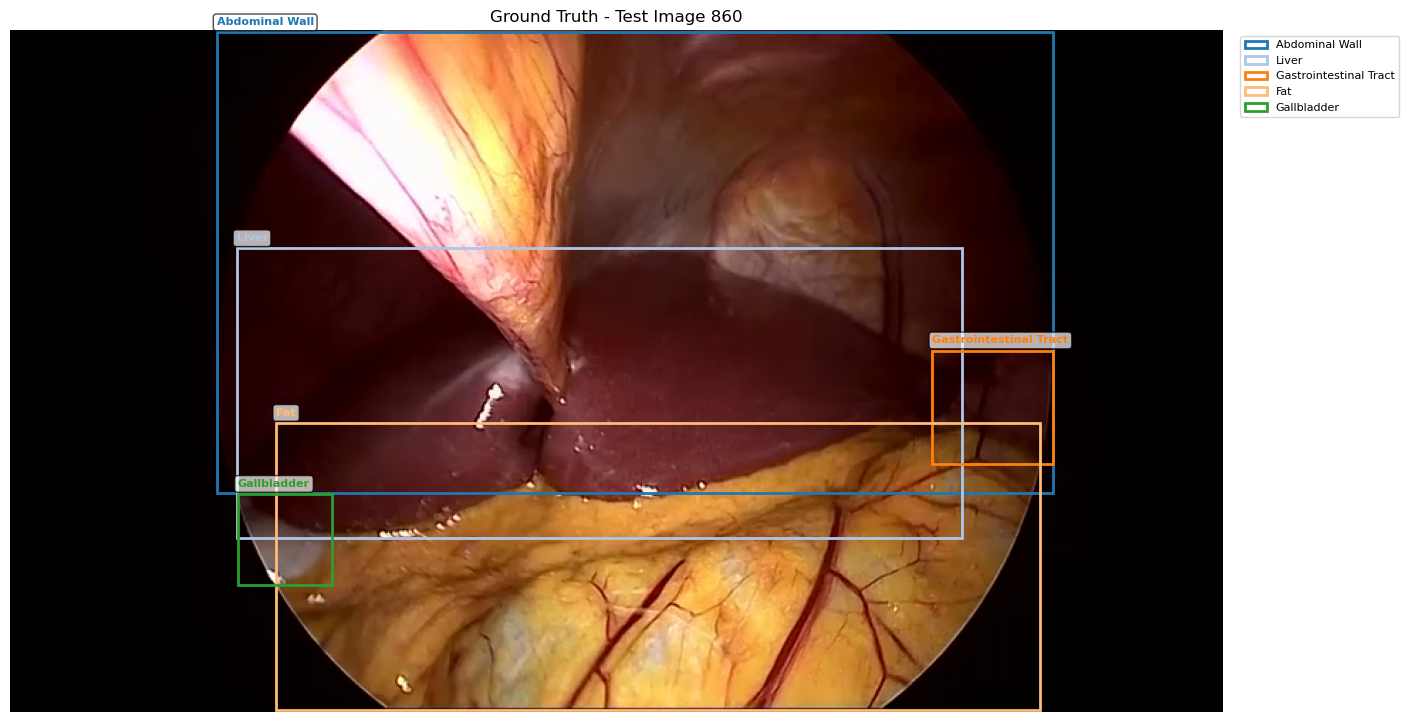

In [29]:
# Visualize bounding boxes on the image
import matplotlib.patches as patches

def visualize_bboxes(image, bboxes_dict, title="Bounding Boxes"):
    """Visualize bounding boxes on an image."""
    fig, ax = plt.subplots(1, 1, figsize=(14, 10))
    ax.imshow(image)
    
    # Color palette for different organs
    colors = plt.cm.tab20(np.linspace(0, 1, 20))
    
    for i, (organ, bbox) in enumerate(bboxes_dict.items()):
        if bbox:
            x1, y1, x2, y2 = bbox
            rect = patches.Rectangle(
                (x1, y1), x2-x1, y2-y1,
                linewidth=2, edgecolor=colors[i % 20],
                facecolor='none', label=organ
            )
            ax.add_patch(rect)
            
            # Add label
            ax.text(x1, y1-5, organ, color=colors[i % 20], 
                   fontsize=8, fontweight='bold',
                   bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.7))
    
    ax.set_title(title)
    ax.axis('off')
    
    # Add legend
    if len(bboxes_dict) > 0:
        ax.legend(loc='upper right', bbox_to_anchor=(1.15, 1), fontsize=8)
    
    plt.tight_layout()
    plt.show()

# Visualize ground truth bboxes
print("\n🎯 GROUND TRUTH BOUNDING BOXES:")
visualize_bboxes(image, gt_bboxes, f"Ground Truth - Test Image {example_idx}")

# Visualize model predictions (if we have parsed output)
if model_name in model_outputs and 'zero_shot' in model_outputs[model_name]:
    try:
        response = model_outputs[model_name]['zero_shot']
        json_match = re.search(r'\{.*\}', response, re.DOTALL)
        if json_match:
            parsed = json.loads(json_match.group())
            
            # Extract bboxes from parsed output
            pred_bboxes = {}
            for organ, data in parsed.items():
                if data.get('present', False) and 'bbox' in data:
                    pred_bboxes[organ] = data['bbox']
            
            print(f"\n🤖 {model_name} PREDICTED BOUNDING BOXES (Zero-shot):")
            visualize_bboxes(image, pred_bboxes, f"{model_name} Predictions (Zero-shot) - Test Image {example_idx}")
            
            # Calculate IoU for each organ
            print("\n📊 IoU scores for each detected organ:")
            for organ in pred_bboxes:
                if organ in gt_bboxes:
                    # Calculate IoU
                    pred = pred_bboxes[organ]
                    gt = gt_bboxes[organ]
                    
                    x1 = max(pred[0], gt[0])
                    y1 = max(pred[1], gt[1])
                    x2 = min(pred[2], gt[2])
                    y2 = min(pred[3], gt[3])
                    
                    if x2 > x1 and y2 > y1:
                        intersection = (x2 - x1) * (y2 - y1)
                        pred_area = (pred[2] - pred[0]) * (pred[3] - pred[1])
                        gt_area = (gt[2] - gt[0]) * (gt[3] - gt[1])
                        union = pred_area + gt_area - intersection
                        iou = intersection / union if union > 0 else 0
                        print(f"  {organ}: IoU = {iou:.3f}")
                    else:
                        print(f"  {organ}: IoU = 0.000 (no overlap)")
                else:
                    print(f"  {organ}: False positive (not in ground truth)")
                    
    except Exception as e:
        print(f"Could not visualize predictions: {e}")

## Example: Raw Prompts and Model Outputs

Let's examine the actual prompts sent to models and their raw responses for one test example.

In [30]:
# Initialize ablation study variables
eval_split = 'test'  # Use test split for evaluation
model_name = MODELS[0]  # Use first model for ablation
ablation_results = {}

print("=" * 80)
print(f"ABLATION STUDY: {model_name}")
print("=" * 80)
print(f"Testing on {len(test_indices)} samples")
print()

# 1. ZERO-SHOT + SEPARATE QUERIES
print("\n1️⃣ Zero-shot + Separate queries (12 API calls per image)")
print("   Each organ detected individually...")

results_zs_separate = evaluator.evaluate_model(
    model_name=model_name,
    test_indices=test_indices,
    detection_mode="separate",  # One query per organ
    prompt_type="standard",
    use_fewshot=False,
    split=eval_split
)

ablation_results['zeroshot_separate'] = results_zs_separate['metrics']
print(f"   ✅ Presence Acc: {results_zs_separate['metrics']['presence_accuracy']:.1%}")
print(f"   ✅ Mean IoU: {results_zs_separate['metrics']['mean_iou']:.3f}")
print(f"   ✅ IoU@0.5: {results_zs_separate['metrics'].get('iou_at_0.5', 0):.1%}")

ABLATION STUDY: gpt-4.1
Testing on 200 samples


1️⃣ Zero-shot + Separate queries (12 API calls per image)
   Each organ detected individually...


Evaluating gpt-4.1 (separate):   1%|          | 22/2400 [01:00<1:52:31,  2.84s/it]ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



Traceback (most recent call last):
  File "/shared_data0/weiqiuy/llm_cholec_organ/src/endopoint/models/openai_gpt.py", line 66, in __call__
    return [f.result() for f in futures]
  File "/shared_data0/weiqiuy/llm_cholec_organ/src/endopoint/models/openai_gpt.py", line 66, in <listcomp>
    return [f.result() for f in futures]
  File "/opt/conda/envs/rapids/lib/python3.10/concurrent/futures/_base.py", line 453, in result
    self._condition.wait(timeout)
  File "/opt/conda/envs/rapids/lib/python3.10/threading.py", line 320, in wait
    waiter.acquire()
KeyboardInterrupt

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/opt/conda/envs/rapids/lib/python3.10/site-packages/IPython/core/interactiveshell.py", line 3457, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/tmp/ipykernel_9348/3045997300.py", line 16, in <module>
    results_zs_separate = evaluator.evaluate_model(
  File "/shared_data0/weiqiuy

TypeError: object of type 'NoneType' has no len()

In [ ]:
# 2. ZERO-SHOT + COMBINED QUERY
print("\n2️⃣ Zero-shot + Combined query (1 API call per image)")
print("   All organs detected together...")

results_zs_combined = evaluator.evaluate_model(
    model_name=model_name,
    test_indices=test_indices,
    detection_mode="combined",  # All organs in one query
    prompt_type="standard",
    use_fewshot=False,
    split=eval_split
)

ablation_results['zeroshot_combined'] = results_zs_combined['metrics']
print(f"   ✅ Presence Acc: {results_zs_combined['metrics']['presence_accuracy']:.1%}")
print(f"   ✅ Mean IoU: {results_zs_combined['metrics']['mean_iou']:.3f}")
print(f"   ✅ IoU@0.5: {results_zs_combined['metrics'].get('iou_at_0.5', 0):.1%}")

In [ ]:
# 3. FEW-SHOT + SEPARATE QUERIES
print("\n3️⃣ Few-shot + Separate queries (12 API calls per image)")
print("   Each organ with specific examples...")

if fewshot_plan is not None:
    results_fs_separate = evaluator.evaluate_model(
        model_name=model_name,
        test_indices=test_indices,
        detection_mode="separate",
        prompt_type="standard",
        use_fewshot=True,
        fewshot_plan=fewshot_plan,  # Organ-specific examples
        split=eval_split
    )
    
    ablation_results['fewshot_separate'] = results_fs_separate['metrics']
    print(f"   ✅ Presence Acc: {results_fs_separate['metrics']['presence_accuracy']:.1%}")
    print(f"   ✅ Mean IoU: {results_fs_separate['metrics']['mean_iou']:.3f}")
    print(f"   ✅ IoU@0.5: {results_fs_separate['metrics'].get('iou_at_0.5', 0):.1%}")
else:
    print("   ⚠️ Skipped - no few-shot plan available")

In [ ]:
# 4. FEW-SHOT + COMBINED QUERY
print("\n4️⃣ Few-shot + Combined query (1 API call per image)")
print("   Creating/loading combined few-shot examples...")

# Load or create combined few-shot examples
combined_examples_file = data_dir / "fewshot_examples_combined.json"

if not combined_examples_file.exists():
    print("   Creating combined few-shot examples...")
    # Create a few examples from training data
    import random
    random.seed(42)
    
    train_indices = random.sample(range(100, 500), 3)  # Pick 3 examples
    combined_examples = []
    
    for idx in train_indices:
        example = dataset_adapter.get_example('train', idx)
        _, lab_tensor = dataset_adapter.example_to_tensors(example)
        mask = lab_tensor.numpy()
        
        detections = {}
        for organ_id in dataset_adapter.label_ids:
            organ_name = dataset_adapter.id2label[organ_id]
            organ_mask = (mask == organ_id).astype(np.uint8)
            
            if organ_mask.sum() >= 50:
                rows, cols = np.where(organ_mask)
                if len(rows) > 0:
                    bbox = [
                        int(cols.min()),
                        int(rows.min()),
                        int(cols.max()),
                        int(rows.max())
                    ]
                    detections[organ_name] = {
                        "present": True,
                        "bbox": bbox
                    }
                else:
                    detections[organ_name] = {"present": False}
            else:
                detections[organ_name] = {"present": False}
        
        combined_examples.append({
            "train_idx": int(idx),
            "detections": detections
        })
    
    # Save for future use
    with open(combined_examples_file, 'w') as f:
        json.dump({"examples": combined_examples}, f, indent=2)
    print(f"   Created {len(combined_examples)} combined examples")
else:
    # Load existing examples
    with open(combined_examples_file, 'r') as f:
        data = json.load(f)
        combined_examples = data.get("examples", [])
    print(f"   Loaded {len(combined_examples)} combined examples")

# Run evaluation with combined few-shot
results_fs_combined = evaluator.evaluate_model(
    model_name=model_name,
    test_indices=test_indices,
    detection_mode="combined",
    prompt_type="standard",
    use_fewshot=True,
    fewshot_examples=combined_examples,  # Image-level examples
    split=eval_split
)

ablation_results['fewshot_combined'] = results_fs_combined['metrics']
print(f"   ✅ Presence Acc: {results_fs_combined['metrics']['presence_accuracy']:.1%}")
print(f"   ✅ Mean IoU: {results_fs_combined['metrics']['mean_iou']:.3f}")
print(f"   ✅ IoU@0.5: {results_fs_combined['metrics'].get('iou_at_0.5', 0):.1%}")

In [ ]:
# ============================================================================
# ABLATION RESULTS COMPARISON
# ============================================================================

print("\n" + "="*80)
print("📊 ABLATION STUDY RESULTS")
print("="*80)

# Create comparison table
comparison_data = []

for approach_name, metrics in ablation_results.items():
    # Parse approach name
    use_fewshot = "fewshot" in approach_name
    mode = "combined" if "combined" in approach_name else "separate"
    
    comparison_data.append({
        'Approach': approach_name.replace('_', ' ').title(),
        'Few-shot': '✓' if use_fewshot else '✗',
        'Mode': mode.capitalize(),
        'API Calls/Image': 1 if mode == "combined" else 12,
        'Presence Acc': f"{metrics['presence_accuracy']*100:.1f}%",
        'Mean IoU': f"{metrics['mean_iou']:.3f}",
        'IoU@0.3': f"{metrics.get('iou_at_0.3', 0)*100:.1f}%",
        'IoU@0.5': f"{metrics.get('iou_at_0.5', 0)*100:.1f}%",
        'IoU@0.75': f"{metrics.get('iou_at_0.75', 0)*100:.1f}%"
    })

# Create DataFrame
comparison_df = pd.DataFrame(comparison_data)
print("\n📈 Performance Comparison:")
print(comparison_df.to_string(index=False))

# Find best approach
best_by_presence = max(ablation_results.items(), key=lambda x: x[1]['presence_accuracy'])
best_by_iou = max(ablation_results.items(), key=lambda x: x[1]['mean_iou'])
best_by_iou50 = max(ablation_results.items(), key=lambda x: x[1].get('iou_at_0.5', 0))

print("\n🏆 Best Approaches:")
print(f"  Presence Detection: {best_by_presence[0]} ({best_by_presence[1]['presence_accuracy']*100:.1f}%)")
print(f"  Mean IoU: {best_by_iou[0]} ({best_by_iou[1]['mean_iou']:.3f})")
print(f"  IoU@0.5: {best_by_iou50[0]} ({best_by_iou50[1].get('iou_at_0.5', 0)*100:.1f}%)")

# Cost comparison
print("\n💰 Efficiency Analysis:")
for approach_name in ablation_results:
    mode = "combined" if "combined" in approach_name else "separate"
    calls_per_image = 1 if mode == "combined" else 12
    total_calls = calls_per_image * len(test_indices)
    print(f"  {approach_name}: {total_calls} total API calls ({calls_per_image} per image)")

# Save comparison
comparison_csv = OUTPUT_DIR / "ablation_comparison.csv"
comparison_df.to_csv(comparison_csv, index=False)
print(f"\n✅ Saved comparison to: {comparison_csv}")

# Recommendation
print("\n" + "="*80)
print("📝 RECOMMENDATION")
print("="*80)

if QUICK_TEST:
    print("⚠️  Note: These results are from a quick test with only", len(test_indices), "samples.")
    print("   Run with QUICK_TEST=False for full evaluation on 200 samples.")
    print()

# Analyze trade-offs
perf_diff_presence = (best_by_presence[1]['presence_accuracy'] - 
                      min(m['presence_accuracy'] for m in ablation_results.values()))
perf_diff_iou = (best_by_iou[1]['mean_iou'] - 
                 min(m['mean_iou'] for m in ablation_results.values()))

if 'combined' in best_by_iou[0] and 'combined' in best_by_presence[0]:
    print("✨ Combined mode performs best overall!")
    print("   - 12x faster (1 vs 12 API calls)")
    print("   - Better or comparable accuracy")
    print("   → Use COMBINED mode for efficiency and performance")
elif abs(perf_diff_presence) < 0.05 and abs(perf_diff_iou) < 0.05:
    print("✨ Performance is similar across approaches (within 5%)")
    print("   → Use COMBINED mode for 12x efficiency gain")
else:
    print("✨ Performance varies significantly across approaches")
    print(f"   - Presence accuracy range: {perf_diff_presence*100:.1f}%")
    print(f"   - IoU range: {perf_diff_iou:.3f}")
    print("   → Consider your priorities: accuracy vs efficiency")

In [ ]:
# Save all ablation results
ablation_results_file = OUTPUT_DIR / "ablation_results.json"
with open(ablation_results_file, 'w') as f:
    json.dump({
        'model': model_name,
        'num_samples': len(test_indices),
        'results': ablation_results,
        'best_approaches': {
            'presence': best_by_presence[0],
            'mean_iou': best_by_iou[0],
            'iou_at_0.5': best_by_iou50[0]
        }
    }, f, indent=2)

print(f"\n📁 All results saved to: {OUTPUT_DIR}")
print("\n✨ Ablation study complete!")